In [1]:
# Optional install for a fresh runtime
%pip install -q exlib matplotlib scikit-image pandas tqdm captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 95.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.3/238.3 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import math
import random
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from skimage import measure, morphology
from tqdm.auto import tqdm

from exlib.datasets.mass_maps import MassMapsDataset, MassMapsFixScore
from exlib.features.vision.watershed import WatershedGroups
from exlib.features.vision.quickshift import QuickshiftGroups
from exlib.features.vision.patch import PatchGroups
from exlib.features.vision.mass_maps import MassMapsOracle, MassMapsOne

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 243MB/s]


device: cuda


## Load the official dataset and FIX scorer

The FIX paper describes the Mass Maps dataset as:
- clean simulations from CosmoGridV1
- input shape `(1, 66, 66)`
- target cosmology parameters
- expert alignment based on **voids** and **clusters**


In [2]:
train_dataset = MassMapsDataset(split="train")
val_dataset = MassMapsDataset(split="validation")
test_dataset = MassMapsDataset(split="test")

print("train:", len(train_dataset))
print("val:", len(val_dataset))
print("test:", len(test_dataset))

massmaps_fix = MassMapsFixScore().to(device)
print("MassMapsFixScore ready.")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-cbc941e131c986(…):   0%|          | 0.00/405M [00:00<?, ?B/s]

data/train-00001-of-00004-be7e10f1e87d86(…):   0%|          | 0.00/405M [00:00<?, ?B/s]

data/train-00002-of-00004-d0bc8800648a4a(…):   0%|          | 0.00/405M [00:00<?, ?B/s]

data/train-00003-of-00004-079a516d87fe74(…):   0%|          | 0.00/405M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/90000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/153 [00:00<?, ?B/s]

train: 90000
val: 10000
test: 10000
MassMapsFixScore ready.


## Helpers

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def to_numpy01(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().float().numpy()
    x = np.asarray(x, dtype=np.float32).squeeze()
    if x.size == 0:
        return x
    lo, hi = float(x.min()), float(x.max())
    if hi - lo < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)


def mask_iou(a, b) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / max(float(union), 1.0)


def dedup_masks(masks, iou_thr=0.70):
    kept = []
    for mask in masks:
        mask = mask.astype(bool)
        if mask.sum() == 0:
            continue
        if all(mask_iou(mask, prev) < iou_thr for prev in kept):
            kept.append(mask)
    return kept


def groups_to_tensor(groups, device):
    arr = np.stack([g.astype(np.float32) for g in groups], axis=0)
    return torch.from_numpy(arr).unsqueeze(0).to(device)


def connected_components(mask, min_area=20):
    labels = measure.label(mask)
    comps = []
    for region in sorted(measure.regionprops(labels), key=lambda r: r.area, reverse=True):
        if region.area < min_area:
            continue
        comp = labels == region.label
        comp = morphology.remove_small_holes(comp, area_threshold=max(16, min_area))
        comp = morphology.remove_small_objects(comp, min_size=min_area)
        if comp.sum() >= min_area:
            comps.append(comp.astype(bool))
    return comps

In [4]:
@torch.no_grad()
def score_groups_massmaps(fix_scorer, image_tensor, groups):
    groups_t = groups_to_tensor(groups, device=next(fix_scorer.parameters()).device if any(True for _ in fix_scorer.parameters()) else device)
    x_t = image_tensor.to(groups_t.device)

    try:
        out = fix_scorer(groups_t, x_t, reduce='none', return_dict=True)
        # expected keys in official notebook:
        # p_void_, p_cluster_, purity, maybe score / alignment
        fix = None
        for key in ["score", "scores", "alignment", "fix", "fixscore"]:
            if key in out:
                val = out[key]
                fix = float(val.flatten()[0].item())
                break
        if fix is None:
            # fallback: if the scorer returns only component scores, combine purity-like summary
            if "purity" in out:
                fix = float(out["purity"].mean().item())
            else:
                raise KeyError(f"Could not find a score key in scorer output keys={list(out.keys())}")
        metrics = {"fix": fix}
        for k in ["p_void_", "p_cluster_", "purity", "ratio_vc", "ratio"]:
            if k in out:
                metrics[k] = float(out[k].flatten().mean().item())
        return metrics
    except TypeError:
        # fallback in case return_dict is unsupported
        out = fix_scorer(groups_t, x_t)
        return {"fix": float(out.flatten()[0].item())}


def diversity_score(groups):
    if len(groups) <= 1:
        return 1.0
    vals = []
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            vals.append(mask_iou(groups[i], groups[j]))
    return 1.0 - float(np.mean(vals))


def metrics_fix_only(fix_scorer, image_tensor, groups):
    out = score_groups_massmaps(fix_scorer, image_tensor, groups)
    out["div"] = diversity_score(groups)
    out["num_groups"] = len(groups)
    return out


def better_by_fix_then_div(a: Dict[str, float], b: Dict[str, float], eps: float = 1e-8) -> bool:
    if a["fix"] > b["fix"] + eps:
        return True
    if abs(a["fix"] - b["fix"]) <= eps and a["div"] > b["div"] + eps:
        return True
    return False

## Build a candidate bank

Unlike ChestX, this notebook does **not** rely on explicit structure masks.

Instead, it builds a proposal bank from segmentation-style group generators:
- watershed
- quickshift
- patch
- optional mass-maps-specific helpers (`MassMapsOne`, `MassMapsOracle`) if available

This is a better fit for the implicit Mass Maps expert alignment.

In [5]:
watershed_groups = WatershedGroups(min_dist=10, compactness=0).to(device)
quickshift_groups = QuickshiftGroups().to(device)
patch_groups = PatchGroups(grid_size=(8, 8), mode='grid').to(device)

try:
    massmaps_one = MassMapsOne().to(device)
except Exception:
    massmaps_one = None

try:
    massmaps_oracle = MassMapsOracle().to(device)
except Exception:
    massmaps_oracle = None

print("baseline group generators ready.")

baseline group generators ready.


In [6]:
def tensor_groups_to_masks(groups_tensor, min_area=20):
    groups_np = groups_tensor.detach().cpu().numpy()
    if groups_np.ndim == 4:
        groups_np = groups_np[0]
    masks = []
    for g in groups_np:
        mask = g > 0
        if mask.sum() < min_area:
            continue
        comps = connected_components(mask, min_area=min_area)
        if comps:
            masks.extend(comps)
        else:
            masks.append(mask.astype(bool))
    return masks


def build_candidate_bank_massmaps(image_tensor, max_candidates=32, min_area=20):
    proposals = []
    provenance = []

    generators = [
        ("watershed", watershed_groups),
        ("quickshift", quickshift_groups),
        ("patch", patch_groups),
    ]
    if massmaps_one is not None:
        generators.append(("massmaps_one", massmaps_one))
    if massmaps_oracle is not None:
        generators.append(("massmaps_oracle", massmaps_oracle))

    for name, generator in generators:
        try:
            groups = generator(image_tensor.to(device))
            masks = tensor_groups_to_masks(groups, min_area=min_area)
            proposals.extend(masks)
            provenance.extend([name] * len(masks))
        except Exception as e:
            print(f"Skipping {name} due to error: {e}")

    # add simple threshold-based proposals directly from image intensity
    image01 = to_numpy01(image_tensor[0, 0])
    for q in [0.05, 0.10, 0.15, 0.85, 0.90, 0.95]:
        thresh = np.quantile(image01, q)
        if q < 0.5:
            base = image01 <= thresh
        else:
            base = image01 >= thresh
        base = morphology.binary_opening(base, morphology.disk(1))
        base = morphology.binary_closing(base, morphology.disk(2))
        comps = connected_components(base, min_area=min_area)
        proposals.extend(comps)
        provenance.extend([f"quantile_{q:.2f}"] * len(comps))

    proposals = dedup_masks(proposals)[:max_candidates]
    provenance = provenance[:len(proposals)]

    return {
        "groups": proposals,
        "provenance": provenance,
        "image01": image01,
    }

In [7]:
def ranked_singletons(fix_scorer, image_tensor, candidate_bank):
    rows = []
    for i, g in enumerate(candidate_bank):
        m = metrics_fix_only(fix_scorer, image_tensor, [g])
        rows.append({
            "idx": i,
            "fix": m["fix"],
            "div": m["div"],
            "p_void_": m.get("p_void_", np.nan),
            "p_cluster_": m.get("p_cluster_", np.nan),
            "purity": m.get("purity", np.nan),
        })
    df = pd.DataFrame(rows).sort_values(["fix", "div"], ascending=False).reset_index(drop=True)
    return df


def seed_init_groups(candidate_bank, singleton_df, init_groups=4):
    idxs = singleton_df["idx"].tolist()[:min(init_groups, len(singleton_df))]
    return [candidate_bank[i].copy() for i in idxs]

## Visualization

In [8]:
def show_overlay(ax, image01, mask, title="", color=(1.0, 0.15, 0.15), alpha=0.35):
    ax.imshow(image01, cmap="viridis")
    rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
    rgba[..., :3] = np.array(color, dtype=np.float32)
    rgba[..., 3] = alpha * mask.astype(np.float32)
    ax.imshow(rgba)
    for contour in measure.find_contours(mask.astype(float), 0.5):
        ax.plot(contour[:, 1], contour[:, 0], color="white", lw=1.0)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


def plot_group_grid(image01, groups, title):
    cols = min(4, max(1, len(groups)))
    rows = int(math.ceil(max(1, len(groups)) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    colors = [
        (1.0, 0.15, 0.15),
        (0.15, 0.85, 1.0),
        (0.35, 1.0, 0.35),
        (1.0, 0.8, 0.1),
        (0.9, 0.3, 1.0),
        (1.0, 0.5, 0.2),
    ]
    for i, ax in enumerate(axes):
        if i < len(groups):
            show_overlay(ax, image01, groups[i], title=f"group {i}", color=colors[i % len(colors)])
        else:
            ax.axis("off")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

## FIX-only search baseline

This is the clean diagnostic baseline:
- accept by **FIX**
- track best by **FIX**
- use diversity only as a tiebreaker

This tells you whether MassMapsFixScore can drive iterative improvement at all.

In [9]:
def mutate_mask(mask, image01, rng):
    op = rng.choice(["dilate", "erode", "open", "close", "fill", "largest", "threshold_grow"])
    k = int(rng.integers(1, 4))
    selem = morphology.disk(k)
    out = mask.copy()

    if op == "dilate":
        out = morphology.binary_dilation(out, selem)
    elif op == "erode":
        out = morphology.binary_erosion(out, selem)
    elif op == "open":
        out = morphology.binary_opening(out, selem)
    elif op == "close":
        out = morphology.binary_closing(out, selem)
    elif op == "fill":
        out = morphology.remove_small_holes(out, area_threshold=36)
    elif op == "largest":
        comps = connected_components(out, min_area=1)
        if comps:
            out = comps[0]
    elif op == "threshold_grow":
        outer = morphology.binary_dilation(out, morphology.disk(2))
        vals = image01[outer]
        if vals.size > 0:
            lo, hi = np.quantile(vals, 0.2), np.quantile(vals, 0.8)
            grow_dark = image01 <= lo
            grow_bright = image01 >= hi
            out = np.logical_or(out, np.logical_and(outer, np.logical_or(grow_dark, grow_bright)))

    out = morphology.remove_small_objects(out.astype(bool), min_size=20)
    out = morphology.remove_small_holes(out.astype(bool), area_threshold=24)
    return out.astype(bool)


def sanitize_groups(groups, candidate_bank, min_area=20):
    proposal = [g for g in dedup_masks(groups) if g.sum() >= min_area]
    if not proposal and len(candidate_bank) > 0:
        proposal = [candidate_bank[0].copy()]
    return proposal


def apply_action(proposal, action, candidate_bank, image01, rng, max_groups=8):
    proposal = [g.copy() for g in proposal]

    if action == "modify" and proposal:
        idx = int(rng.integers(0, len(proposal)))
        proposal[idx] = mutate_mask(proposal[idx], image01, rng)

    elif action == "add" and len(proposal) < max_groups and candidate_bank:
        proposal.append(candidate_bank[int(rng.integers(0, len(candidate_bank)))].copy())

    elif action == "delete" and len(proposal) > 1:
        proposal.pop(int(rng.integers(0, len(proposal))))

    elif action == "replace" and proposal and candidate_bank:
        idx = int(rng.integers(0, len(proposal)))
        proposal[idx] = candidate_bank[int(rng.integers(0, len(candidate_bank)))].copy()

    elif action == "merge" and len(proposal) > 1:
        i, j = sorted(rng.choice(len(proposal), size=2, replace=False).tolist())
        proposal[i] = np.logical_or(proposal[i], proposal[j])
        proposal.pop(j)

    return sanitize_groups(proposal, candidate_bank)

In [10]:
def improve_groups_fix_only(
    fix_scorer,
    image_tensor,
    init_groups,
    candidate_bank,
    num_steps=120,
    max_groups=8,
    seed=0,
):
    rng = np.random.default_rng(seed)
    image01 = to_numpy01(image_tensor[0, 0])

    current = [g.copy() for g in init_groups]
    current_metrics = metrics_fix_only(fix_scorer, image_tensor, current)

    best = [g.copy() for g in current]
    best_metrics = dict(current_metrics)

    history = [dict(step=0, accepted=True, action="init", **current_metrics)]

    for step in range(1, num_steps + 1):
        action = rng.choice(["modify", "add", "delete", "replace", "merge"])
        proposal = apply_action(current, action, candidate_bank, image01, rng, max_groups=max_groups)
        proposal_metrics = metrics_fix_only(fix_scorer, image_tensor, proposal)

        accept = better_by_fix_then_div(proposal_metrics, current_metrics)
        if accept:
            current = [g.copy() for g in proposal]
            current_metrics = dict(proposal_metrics)

        if better_by_fix_then_div(current_metrics, best_metrics):
            best = [g.copy() for g in current]
            best_metrics = dict(current_metrics)

        history.append(dict(step=step, accepted=accept, action=action, **current_metrics))

    return best, history, best_metrics

## Stronger search: random restarts and beam search

In [11]:
def run_fix_search_with_restarts(
    fix_scorer,
    image_tensor,
    candidate_bank,
    n_restarts=8,
    num_steps=80,
    init_groups=4,
    max_groups=8,
    seed=0,
):
    rng = np.random.default_rng(seed)
    singleton_df = ranked_singletons(fix_scorer, image_tensor, candidate_bank)

    all_runs = []
    best_groups = None
    best_metrics = None

    for r in range(n_restarts):
        if r == 0:
            start_groups = seed_init_groups(candidate_bank, singleton_df, init_groups=init_groups)
        else:
            order = rng.permutation(len(candidate_bank)).tolist()
            chosen = order[:min(init_groups, len(order))]
            start_groups = [candidate_bank[i].copy() for i in chosen]

        groups, history, metrics = improve_groups_fix_only(
            fix_scorer=fix_scorer,
            image_tensor=image_tensor,
            init_groups=start_groups,
            candidate_bank=candidate_bank,
            num_steps=num_steps,
            max_groups=max_groups,
            seed=int(rng.integers(0, 10_000_000)),
        )
        all_runs.append({"restart": r, "groups": groups, "history": history, "metrics": metrics})

        if best_metrics is None or better_by_fix_then_div(metrics, best_metrics):
            best_groups = [g.copy() for g in groups]
            best_metrics = dict(metrics)

    return best_groups, all_runs, best_metrics, singleton_df

In [12]:
def beam_search_fix(
    fix_scorer,
    image_tensor,
    candidate_bank,
    beam_width=4,
    expansions_per_state=4,
    num_rounds=12,
    max_groups=8,
    seed=0,
):
    rng = np.random.default_rng(seed)
    image01 = to_numpy01(image_tensor[0, 0])

    singleton_df = ranked_singletons(fix_scorer, image_tensor, candidate_bank)
    beam = []

    for idx in singleton_df["idx"].tolist()[:beam_width]:
        groups = [candidate_bank[idx].copy()]
        metrics = metrics_fix_only(fix_scorer, image_tensor, groups)
        beam.append({"groups": groups, "metrics": metrics, "trace": [f"start:{idx}"]})

    if not beam:
        raise ValueError("Candidate bank is empty.")

    history = []

    for round_idx in range(num_rounds):
        candidates = []
        for state in beam:
            candidates.append(state)
            for _ in range(expansions_per_state):
                action = rng.choice(["modify", "add", "delete", "replace", "merge"])
                proposal = apply_action(state["groups"], action, candidate_bank, image01, rng, max_groups=max_groups)
                metrics = metrics_fix_only(fix_scorer, image_tensor, proposal)
                candidates.append({
                    "groups": [g.copy() for g in proposal],
                    "metrics": metrics,
                    "trace": state["trace"] + [action],
                })

        candidates.sort(key=lambda s: (s["metrics"]["fix"], s["metrics"]["div"]), reverse=True)

        next_beam = []
        for cand in candidates:
            keep = True
            for existing in next_beam:
                if len(cand["groups"]) == len(existing["groups"]):
                    mean_iou = np.mean([
                        max(mask_iou(g, h) for h in existing["groups"])
                        for g in cand["groups"]
                    ])
                    if mean_iou > 0.80:
                        keep = False
                        break
            if keep:
                next_beam.append(cand)
            if len(next_beam) >= beam_width:
                break

        beam = next_beam
        history.append({
            "round": round_idx,
            "beam_fix": [s["metrics"]["fix"] for s in beam],
            "beam_div": [s["metrics"]["div"] for s in beam],
        })

    best = beam[0]
    return best["groups"], history, best["metrics"], best["trace"]

## Paper-aligned RL for feature selection

This section replaces the earlier action-policy RL with the **feature-subset RL methodology**:

- **state** = current subset of candidate feature masks
- **action** = add one unseen candidate mask
- **reward** = `FIX(next_subset) - FIX(current_subset)`
- **state value update** = TD(0)
- **feature scoring** = Average Of Reward (AOR), maintained incrementally
- **exploration** = random on unseen states, epsilon-greedy on revisited states
- **episode initialization** = random subset start, as described in the paper

This is much closer to the feature-selection MDP in the paper than the earlier edit-action policy.


In [13]:

from collections import defaultdict

def make_subset_score_cache():
    return {}

def canonical_state(indices):
    return tuple(sorted(int(i) for i in indices))

def score_subset_cached(fix_scorer, image_tensor, candidate_bank, state, cache):
    state = canonical_state(state)
    if state not in cache:
        groups = [candidate_bank[i].copy() for i in state]
        if len(groups) == 0:
            # empty subset is given a neutral baseline
            cache[state] = {
                "fix": 0.0,
                "div": 1.0,
                "num_groups": 0,
            }
        else:
            cache[state] = metrics_fix_only(fix_scorer, image_tensor, groups)
    return dict(cache[state])

def incremental_mean(old_mean, count, new_value):
    if count <= 0:
        return float(new_value)
    return float(old_mean + (new_value - old_mean) / count)

def available_actions(state, n_features, max_groups=None):
    state_set = set(state)
    actions = [i for i in range(n_features) if i not in state_set]
    if max_groups is not None and len(state) >= max_groups:
        return []
    return actions

def rank_actions_for_state(state, actions, sa_aor, global_aor, singleton_rank=None):
    vals = []
    singleton_bonus = {}
    if singleton_rank is not None and len(singleton_rank) > 0:
        max_rank = max(singleton_rank.values()) + 1
        singleton_bonus = {k: (max_rank - v) / max_rank for k, v in singleton_rank.items()}
    for a in actions:
        key = (canonical_state(state), int(a))
        base = sa_aor.get(key, global_aor.get(int(a), 0.0))
        vals.append(base + 0.05 * singleton_bonus.get(int(a), 0.0))
    order = np.argsort(vals)[::-1]
    return [int(actions[i]) for i in order], [float(vals[i]) for i in order]

def choose_action_paper_rl(
    state,
    actions,
    state_visits,
    sa_aor,
    global_aor,
    epsilon,
    rng,
    singleton_rank=None,
    top_action_k=None,
):
    state = canonical_state(state)
    if len(actions) == 0:
        return None, "terminal"

    ranked_actions, ranked_vals = rank_actions_for_state(
        state=state,
        actions=actions,
        sa_aor=sa_aor,
        global_aor=global_aor,
        singleton_rank=singleton_rank,
    )

    if top_action_k is not None and top_action_k > 0:
        restricted = ranked_actions[: min(top_action_k, len(ranked_actions))]
    else:
        restricted = ranked_actions

    # paper-style: unseen state => random exploration
    if state_visits[state] == 0:
        return int(rng.choice(actions)), "random_unseen"

    if rng.random() < epsilon:
        if len(restricted) > 0 and rng.random() < 0.8:
            return int(rng.choice(restricted)), "epsilon_topk"
        return int(rng.choice(actions)), "epsilon"

    return int(restricted[0]), "greedy"

def build_warm_start_states(
    candidate_bank,
    singleton_df,
    max_groups,
    rng,
    n_random=16,
):
    n_features = len(candidate_bank)
    starts = [tuple()]
    if singleton_df is not None and len(singleton_df) > 0:
        top_idx = singleton_df.sort_values(["fix", "div"], ascending=[False, False])["idx"].astype(int).tolist()
        for k in range(1, min(max_groups, len(top_idx)) + 1):
            starts.append(canonical_state(top_idx[:k]))
        # a few random subsets from the strong singleton pool
        pool = top_idx[: min(len(top_idx), max(8, 2 * max_groups))]
        for _ in range(n_random):
            if len(pool) == 0:
                break
            k = int(rng.integers(1, min(max_groups, len(pool)) + 1))
            starts.append(canonical_state(rng.choice(pool, size=k, replace=False).tolist()))
    else:
        for _ in range(n_random):
            k = int(rng.integers(0, min(max_groups, n_features) + 1))
            starts.append(canonical_state(rng.choice(n_features, size=k, replace=False).tolist()) if k > 0 else [])
    # unique while preserving order
    dedup = []
    seen = set()
    for st in starts:
        st = canonical_state(st)
        if st not in seen:
            dedup.append(st)
            seen.add(st)
    return dedup

def plot_selected_features(image01, candidate_bank, selected_state, title):
    groups = [candidate_bank[i] for i in selected_state]
    if len(groups) == 0:
        plt.figure(figsize=(5, 5))
        plt.imshow(image01, cmap="viridis")
        plt.title(title + " (empty)")
        plt.axis("off")
        plt.show()
        return
    plot_group_grid(image01, groups, title)

def overlay_many_masks(image01, candidate_bank, selected_state, title="Combined selected features"):
    plt.figure(figsize=(6, 6))
    plt.imshow(image01, cmap="viridis")
    colors = [
        (1.0, 0.15, 0.15),
        (0.15, 0.85, 1.0),
        (0.35, 1.0, 0.35),
        (1.0, 0.8, 0.1),
        (0.9, 0.3, 1.0),
        (1.0, 0.5, 0.2),
        (0.7, 0.7, 1.0),
        (0.3, 1.0, 0.8),
    ]
    for j, idx in enumerate(selected_state):
        mask = candidate_bank[idx]
        rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
        rgba[..., :3] = np.array(colors[j % len(colors)], dtype=np.float32)
        rgba[..., 3] = 0.22 * mask.astype(np.float32)
        plt.imshow(rgba)
        for contour in measure.find_contours(mask.astype(float), 0.5):
            plt.plot(contour[:, 1], contour[:, 0], color="white", lw=0.8)
    plt.title(title)
    plt.axis("off")
    plt.show()


In [14]:

def train_feature_rl_td_aor(
    fix_scorer,
    image_tensor,
    candidate_bank,
    episodes=3000,
    alpha=0.12,
    gamma=0.97,
    epsilon_start=0.45,
    epsilon_end=0.03,
    max_groups=8,
    random_start_min=0,
    random_start_max=4,
    no_improve_patience=16,
    top_action_k=12,
    warm_start_every=3,
    seed=0,
):
    rng = np.random.default_rng(seed)
    n_features = len(candidate_bank)
    if n_features == 0:
        raise ValueError("Candidate bank is empty.")

    cache = make_subset_score_cache()
    V = defaultdict(float)
    state_visits = defaultdict(int)
    sa_counts = defaultdict(int)
    sa_aor = {}
    global_counts = defaultdict(int)
    global_aor = {}

    singleton_df = ranked_singletons(fix_scorer, image_tensor, candidate_bank)
    singleton_rank = {int(idx): rank for rank, idx in enumerate(singleton_df.sort_values(["fix", "div"], ascending=[False, False])["idx"].astype(int).tolist())}
    warm_starts = build_warm_start_states(candidate_bank, singleton_df, max_groups=max_groups, rng=rng, n_random=24)

    best_state = tuple()
    best_metrics = score_subset_cached(fix_scorer, image_tensor, candidate_bank, best_state, cache)

    history = []
    max_start = min(random_start_max, max_groups, n_features)

    for ep in tqdm(range(episodes), desc="paper-RL+ episodes"):
        eps = epsilon_start + (epsilon_end - epsilon_start) * (ep / max(episodes - 1, 1))

        use_warm = (len(warm_starts) > 0) and (ep % max(warm_start_every, 1) == 0)
        if use_warm:
            start_state = warm_starts[int(rng.integers(0, len(warm_starts)))]
            start_mode = "warm"
        else:
            start_k = int(rng.integers(random_start_min, max_start + 1)) if max_start >= random_start_min else 0
            if start_k > 0:
                start_state = canonical_state(rng.choice(n_features, size=start_k, replace=False).tolist())
            else:
                start_state = tuple()
            start_mode = "random"

        state = start_state
        state_metrics = score_subset_cached(fix_scorer, image_tensor, candidate_bank, state, cache)

        if better_by_fix_then_div(state_metrics, best_metrics):
            best_state = state
            best_metrics = dict(state_metrics)

        episode_return = 0.0
        episode_best_fix = state_metrics["fix"]
        steps = 0
        stagnant = 0

        while True:
            actions = available_actions(state, n_features, max_groups=max_groups)
            if len(actions) == 0:
                break

            action, action_mode = choose_action_paper_rl(
                state=state,
                actions=actions,
                state_visits=state_visits,
                sa_aor=sa_aor,
                global_aor=global_aor,
                epsilon=eps,
                rng=rng,
                singleton_rank=singleton_rank,
                top_action_k=top_action_k,
            )
            if action is None:
                break

            next_state = canonical_state(list(state) + [int(action)])
            next_metrics = score_subset_cached(fix_scorer, image_tensor, candidate_bank, next_state, cache)

            reward = float(next_metrics["fix"] - state_metrics["fix"])
            td_target = reward + gamma * V[next_state]
            td_error = td_target - V[state]
            V[state] += alpha * td_error

            state_visits[state] += 1

            key = (state, int(action))
            sa_counts[key] += 1
            sa_aor[key] = incremental_mean(sa_aor.get(key, 0.0), sa_counts[key], reward)

            global_counts[int(action)] += 1
            global_aor[int(action)] = incremental_mean(global_aor.get(int(action), 0.0), global_counts[int(action)], reward)

            episode_return += reward
            steps += 1

            if next_metrics["fix"] > episode_best_fix + 1e-8:
                episode_best_fix = next_metrics["fix"]
                stagnant = 0
            else:
                stagnant += 1

            if better_by_fix_then_div(next_metrics, best_metrics):
                best_state = next_state
                best_metrics = dict(next_metrics)

            state = next_state
            state_metrics = next_metrics

            if stagnant >= no_improve_patience:
                break

        history.append({
            "episode": ep,
            "epsilon": eps,
            "start_mode": start_mode,
            "start_size": len(start_state),
            "steps": steps,
            "episode_return": episode_return,
            "episode_best_fix": episode_best_fix,
            "global_best_fix": best_metrics["fix"],
            "visited_states": len(state_visits),
            "cache_size": len(cache),
        })

    train_df = pd.DataFrame(history)

    feature_rows = []
    for feat_idx in range(n_features):
        feature_rows.append({
            "idx": feat_idx,
            "global_aor": global_aor.get(feat_idx, 0.0),
            "global_count": global_counts.get(feat_idx, 0),
            "singleton_fix": float(singleton_df.loc[singleton_df["idx"] == feat_idx, "fix"].iloc[0]) if feat_idx in singleton_df["idx"].values else np.nan,
        })
    feature_df = pd.DataFrame(feature_rows).sort_values(
        ["global_aor", "global_count", "singleton_fix"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return {
        "V": V,
        "sa_aor": sa_aor,
        "sa_counts": sa_counts,
        "global_aor": global_aor,
        "global_counts": global_counts,
        "state_visits": state_visits,
        "cache": cache,
        "train_df": train_df,
        "feature_df": feature_df,
        "best_state": best_state,
        "best_metrics": best_metrics,
        "singleton_df": singleton_df,
        "warm_starts": warm_starts,
        "config": {
            "episodes": episodes,
            "alpha": alpha,
            "gamma": gamma,
            "epsilon_start": epsilon_start,
            "epsilon_end": epsilon_end,
            "max_groups": max_groups,
            "top_action_k": top_action_k,
        },
    }

def greedy_rollout_from_aor(
    fix_scorer,
    image_tensor,
    candidate_bank,
    rl_artifact,
    start_state=None,
    max_groups=8,
):
    if start_state is None:
        state = tuple()
    else:
        state = canonical_state(start_state)

    cache = rl_artifact["cache"]
    state_metrics = score_subset_cached(fix_scorer, image_tensor, candidate_bank, state, cache)
    rows = [{
        "step": 0,
        "selected": list(state),
        "fix": state_metrics["fix"],
        "div": state_metrics["div"],
        "num_groups": state_metrics["num_groups"],
        "choice": None,
    }]

    while True:
        actions = available_actions(state, len(candidate_bank), max_groups=max_groups)
        if len(actions) == 0:
            break

        ranked_actions, ranked_vals = rank_actions_for_state(
            state=state,
            actions=actions,
            sa_aor=rl_artifact["sa_aor"],
            global_aor=rl_artifact["global_aor"],
            singleton_rank={int(idx): rank for rank, idx in enumerate(rl_artifact["singleton_df"]["idx"].astype(int).tolist())},
        )
        if len(ranked_actions) == 0:
            break

        action = int(ranked_actions[0])
        next_state = canonical_state(list(state) + [action])
        next_metrics = score_subset_cached(fix_scorer, image_tensor, candidate_bank, next_state, cache)
        reward = float(next_metrics["fix"] - state_metrics["fix"])

        if reward <= 1e-8:
            break

        state = next_state
        state_metrics = next_metrics
        rows.append({
            "step": len(rows),
            "selected": list(state),
            "fix": state_metrics["fix"],
            "div": state_metrics["div"],
            "num_groups": state_metrics["num_groups"],
            "choice": action,
            "marginal_gain": reward,
        })

    return state, pd.DataFrame(rows), state_metrics

def refine_state_with_local_search(
    fix_scorer,
    image_tensor,
    candidate_bank,
    state,
    num_steps=36,
    max_groups=8,
    seed=0,
):
    groups = [candidate_bank[i].copy() for i in canonical_state(state)]
    if len(groups) == 0:
        return tuple(), metrics_fix_only(fix_scorer, image_tensor, groups), groups
    best_groups, _, best_metrics = improve_groups_fix_only(
        fix_scorer=fix_scorer,
        image_tensor=image_tensor,
        init_groups=groups,
        candidate_bank=candidate_bank,
        num_steps=num_steps,
        max_groups=max_groups,
        seed=seed,
    )
    return canonical_state(state), best_metrics, best_groups


## Single-image walkthrough with paper-aligned RL


In [31]:

TEST_INDEX = 12
FIX_STEPS = 80
MAX_CANDIDATES = 32
INIT_GROUPS = 4
MAX_GROUPS = 8

# Much larger RL budget plus warm starts / top-k action restriction
RL_EPISODES = 10000
RL_ALPHA = 0.12
RL_GAMMA = 0.97
RL_EPS_START = 0.45
RL_EPS_END = 0.03
RL_RANDOM_START_MAX = 4
RL_PATIENCE = 16
RL_TOP_ACTION_K = 12

set_seed(42)

item = test_dataset[TEST_INDEX]
image_tensor = item["input"].unsqueeze(0).float()
label = item["label"]

bank = build_candidate_bank_massmaps(
    image_tensor=image_tensor,
    max_candidates=MAX_CANDIDATES,
    min_area=20,
)
print("candidate bank size:", len(bank["groups"]))

singleton_df = ranked_singletons(massmaps_fix, image_tensor, bank["groups"])
display(singleton_df.head(10))

init_groups = seed_init_groups(bank["groups"], singleton_df, init_groups=INIT_GROUPS)
init_metrics = metrics_fix_only(massmaps_fix, image_tensor, init_groups)
print("initial metrics:", init_metrics)


candidate bank size: 32


,idx,fix,div,p_void_,p_cluster_,purity
0,1,0.626147,1.0,0.631793,1.359692e-03,0.626147
1,0,0.000000,1.0,0.519294,5.513662e-03,0.502732
2,2,0.000000,1.0,0.580882,9.999970e-07,0.580872
3,3,0.000000,1.0,0.479338,9.999970e-07,0.479329
4,4,0.000000,1.0,0.342857,5.714368e-02,0.281665
5,5,0.000000,1.0,0.689654,9.999970e-07,0.689645
6,6,0.000000,1.0,0.545454,9.999970e-07,0.545445
7,7,0.000000,1.0,0.596638,8.404337e-03,0.573096
8,8,0.000000,1.0,0.749999,9.999970e-07,0.749989
9,9,0.000000,1.0,0.378788,1.515247e-02,0.347612


initial metrics: {'fix': 0.6261469721794128, 'p_void_': 0.5528266429901123, 'p_cluster_': 0.0017188384663313627, 'purity': 0.5472700595855713, 'div': 1.0, 'num_groups': 4}


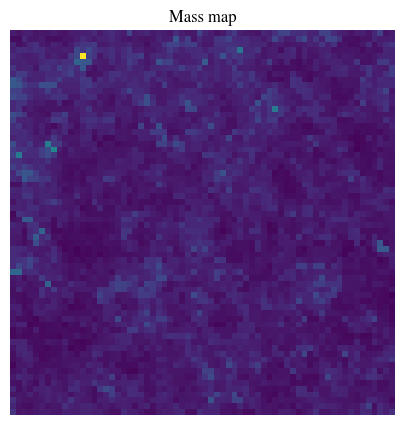

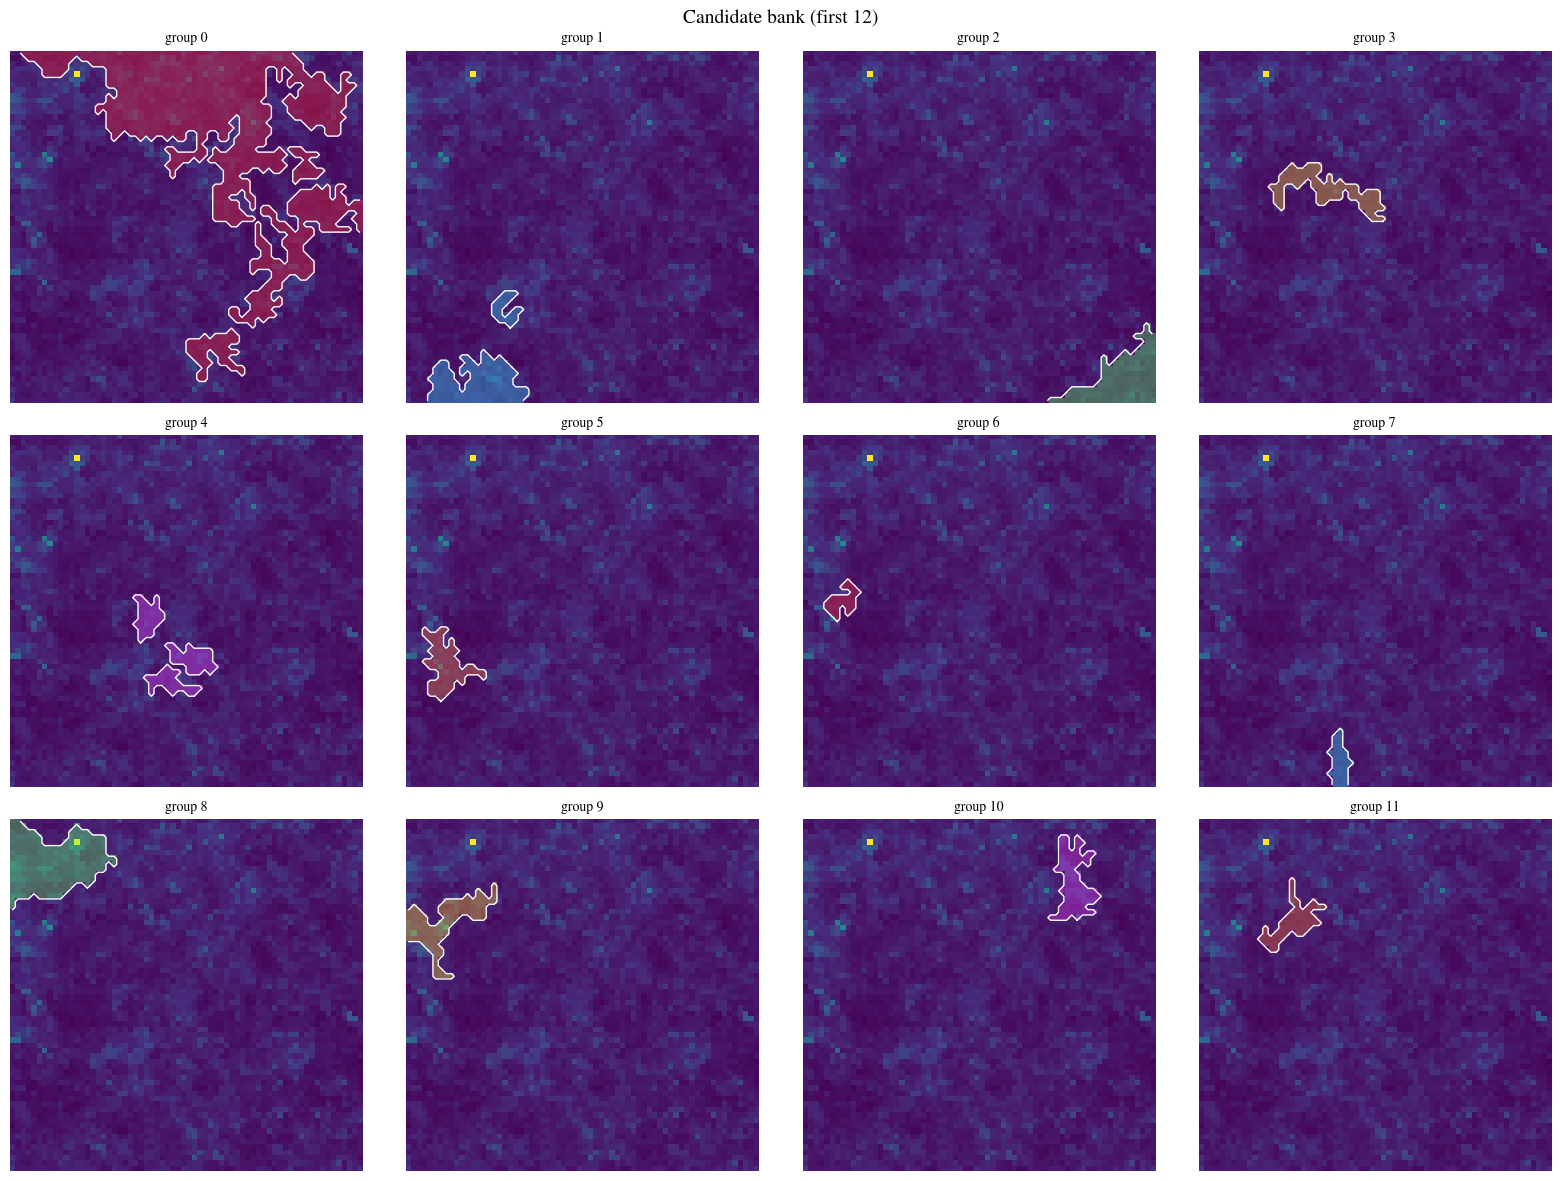

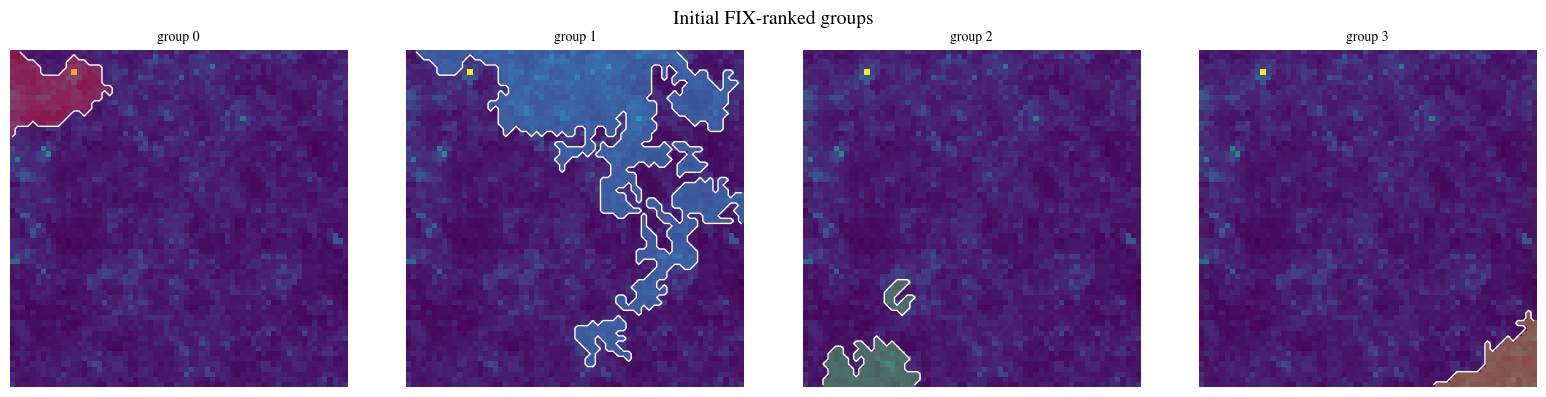

In [16]:
plt.figure(figsize=(5, 5))
plt.imshow(bank["image01"], cmap="viridis")
plt.title("Mass map")
plt.axis("off")
plt.show()

plot_group_grid(bank["image01"], bank["groups"][:12], "Candidate bank (first 12)")
plot_group_grid(bank["image01"], init_groups, "Initial FIX-ranked groups")


best FIX-only metrics: {'fix': 0.7005103230476379, 'p_void_': 0.570008397102356, 'p_cluster_': 0.0013791655655950308, 'purity': 0.5658608675003052, 'div': 1.0, 'num_groups': 4}


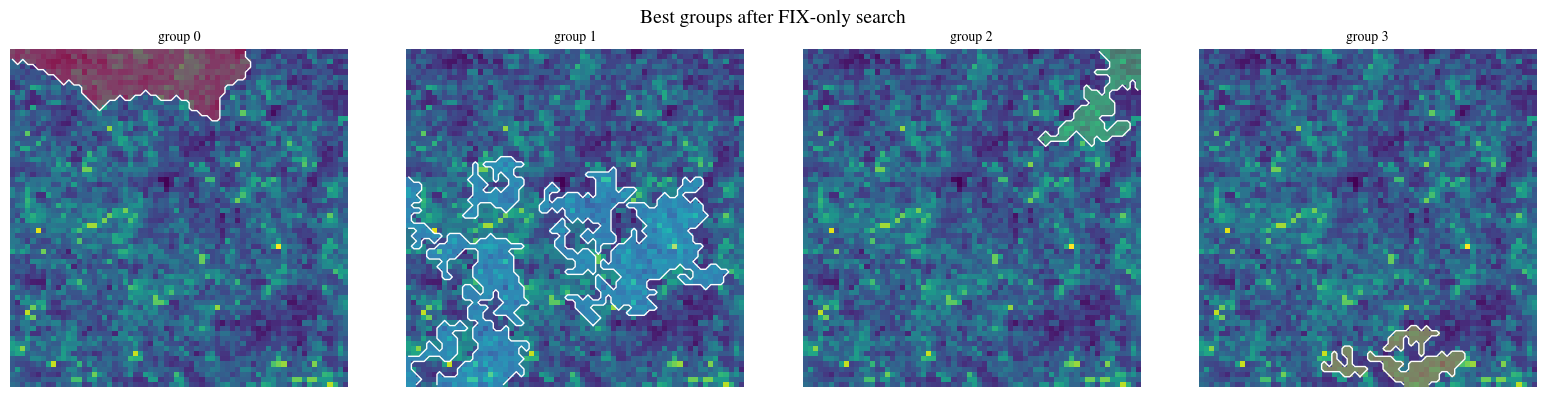

In [32]:
best_fix_groups, fix_history, best_fix_metrics = improve_groups_fix_only(
    fix_scorer=massmaps_fix,
    image_tensor=image_tensor,
    init_groups=init_groups,
    candidate_bank=bank["groups"],
    num_steps=FIX_STEPS,
    max_groups=MAX_GROUPS,
    seed=0,
)

print("best FIX-only metrics:", best_fix_metrics)
plot_group_grid(bank["image01"], best_fix_groups, "Best groups after FIX-only search")


,step,accepted,action,fix,p_void_,p_cluster_,purity,div,num_groups
0,0,True,init,0.626147,0.552827,0.001719,0.547270,1.0,4
1,1,False,merge,0.626147,0.552827,0.001719,0.547270,1.0,4
2,2,False,add,0.626147,0.552827,0.001719,0.547270,1.0,4
3,3,True,modify,0.700510,0.570008,0.001379,0.565861,1.0,4
4,4,False,replace,0.700510,0.570008,0.001379,0.565861,1.0,4


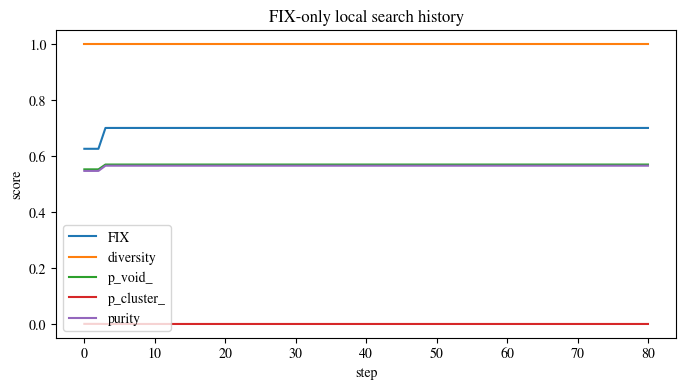

In [33]:
fix_df = pd.DataFrame(fix_history)
display(fix_df.head())

plt.figure(figsize=(8, 4))
plt.plot(fix_df["step"], fix_df["fix"], label="FIX")
plt.plot(fix_df["step"], fix_df["div"], label="diversity")
if "p_void_" in fix_df.columns:
    plt.plot(fix_df["step"], fix_df["p_void_"], label="p_void_")
if "p_cluster_" in fix_df.columns:
    plt.plot(fix_df["step"], fix_df["p_cluster_"], label="p_cluster_")
if "purity" in fix_df.columns:
    plt.plot(fix_df["step"], fix_df["purity"], label="purity")
plt.xlabel("step")
plt.ylabel("score")
plt.title("FIX-only local search history")
plt.legend()
plt.show()


## Stronger non-RL baselines: random restarts and beam search


,restart,fix,div,num_groups
0,0,0.651239,1.0,4
2,2,0.642816,1.0,3
5,5,0.635966,1.0,3
6,6,0.635922,1.0,4
7,7,0.626147,1.0,4
3,3,0.626147,1.0,5
1,1,0.000000,1.0,4
4,4,0.000000,1.0,4


best restart metrics: {'fix': 0.6512388586997986, 'p_void_': 0.559351921081543, 'p_cluster_': 0.0017903485568240285, 'purity': 0.5535430312156677, 'div': 1.0, 'num_groups': 4}


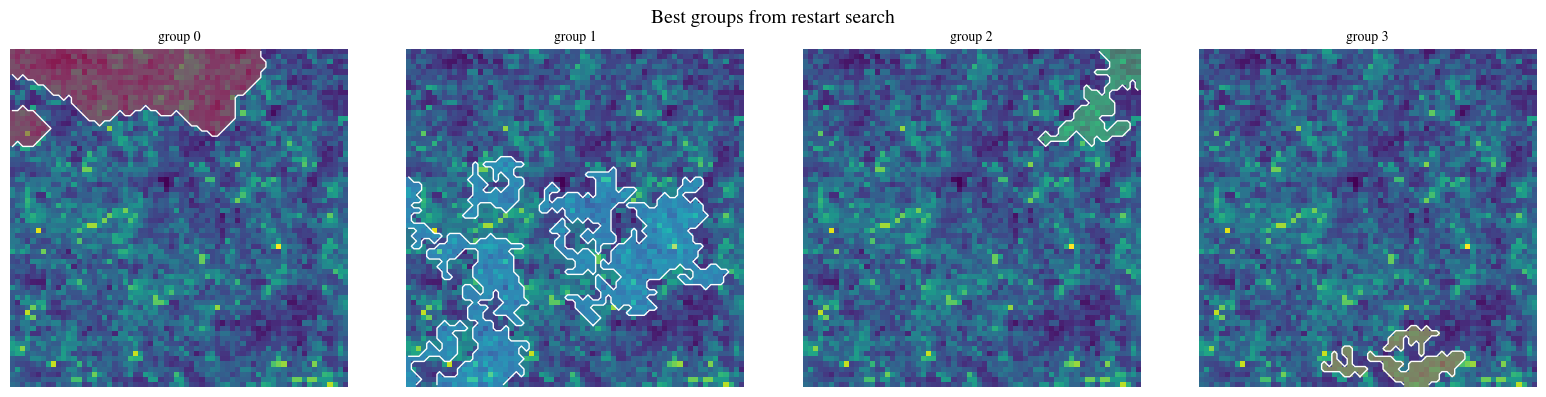

In [34]:
restart_best_groups, restart_runs, restart_best_metrics, singleton_df = run_fix_search_with_restarts(
    fix_scorer=massmaps_fix,
    image_tensor=image_tensor,
    candidate_bank=bank["groups"],
    n_restarts=8,
    num_steps=60,
    init_groups=INIT_GROUPS,
    max_groups=MAX_GROUPS,
    seed=0,
)

restart_table = pd.DataFrame([
    {
        "restart": run["restart"],
        "fix": run["metrics"]["fix"],
        "div": run["metrics"]["div"],
        "num_groups": run["metrics"]["num_groups"],
    }
    for run in restart_runs
]).sort_values("fix", ascending=False)

display(restart_table)
print("best restart metrics:", restart_best_metrics)
plot_group_grid(bank["image01"], restart_best_groups, "Best groups from restart search")


beam metrics: {'fix': 0.7005103230476379, 'p_void_': 0.6485788226127625, 'p_cluster_': 0.004202668555080891, 'purity': 0.6368030309677124, 'div': 1.0, 'num_groups': 2}
beam trace: ['start:1', 'add', 'replace', 'modify']


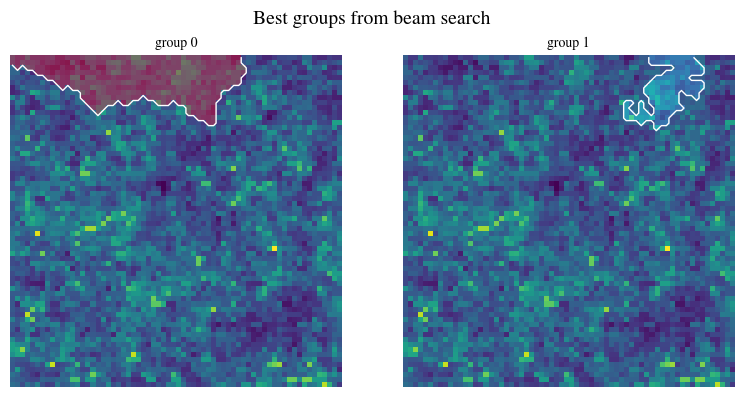

In [35]:
beam_groups, beam_history, beam_metrics, beam_trace = beam_search_fix(
    fix_scorer=massmaps_fix,
    image_tensor=image_tensor,
    candidate_bank=bank["groups"],
    beam_width=4,
    expansions_per_state=4,
    num_rounds=10,
    max_groups=MAX_GROUPS,
    seed=0,
)

print("beam metrics:", beam_metrics)
print("beam trace:", beam_trace)
plot_group_grid(bank["image01"], beam_groups, "Best groups from beam search")


## Train the stronger paper-style RL selector (paper core + practical upgrades)

In [36]:

paper_rl = train_feature_rl_td_aor(
    fix_scorer=massmaps_fix,
    image_tensor=image_tensor,
    candidate_bank=bank["groups"],
    episodes=RL_EPISODES,
    alpha=RL_ALPHA,
    gamma=RL_GAMMA,
    epsilon_start=RL_EPS_START,
    epsilon_end=RL_EPS_END,
    max_groups=MAX_GROUPS,
    random_start_min=0,
    random_start_max=RL_RANDOM_START_MAX,
    no_improve_patience=RL_PATIENCE,
    top_action_k=RL_TOP_ACTION_K,
    seed=0,
)

print("RL best metrics:", paper_rl["best_metrics"])
print("RL best state:", paper_rl["best_state"])
display(paper_rl["feature_df"].head(12))


paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

RL best metrics: {'fix': 0.6261469721794128, 'p_void_': 0.5528266429901123, 'p_cluster_': 0.0017188384663313627, 'purity': 0.5472700595855713, 'div': 1.0, 'num_groups': 4}
RL best state: (0, 1, 2, 3)


,idx,global_aor,global_count,singleton_fix
0,1,0.626147,5391,0.626147
1,0,0.000000,4587,0.000000
2,2,0.000000,4254,0.000000
3,3,0.000000,3728,0.000000
4,4,0.000000,3562,0.000000
5,5,0.000000,3405,0.000000
6,6,0.000000,2903,0.000000
7,7,0.000000,1923,0.000000
8,11,0.000000,1077,0.000000
9,13,0.000000,1050,0.000000


,episode,epsilon,start_mode,start_size,steps,episode_return,episode_best_fix,global_best_fix,visited_states,cache_size
9995,9995,0.030168,random,2,6,0.626147,0.626147,0.626147,21107,26832
9996,9996,0.030126,warm,3,5,0.626147,0.626147,0.626147,21107,26832
9997,9997,0.030084,random,3,5,0.000000,0.000000,0.626147,21112,26838
9998,9998,0.030042,random,1,7,0.626147,0.626147,0.626147,21112,26838
9999,9999,0.030000,warm,6,2,0.626147,0.626147,0.626147,21112,26838


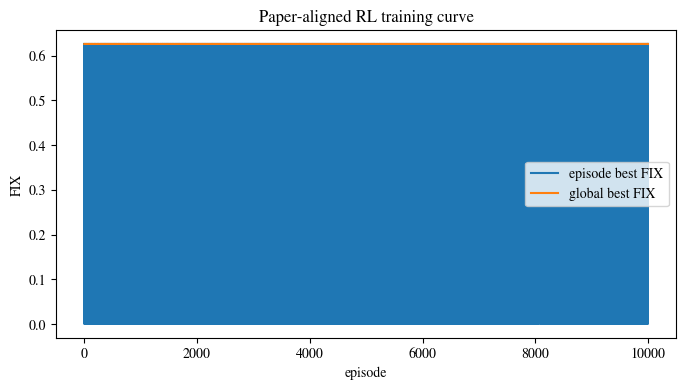

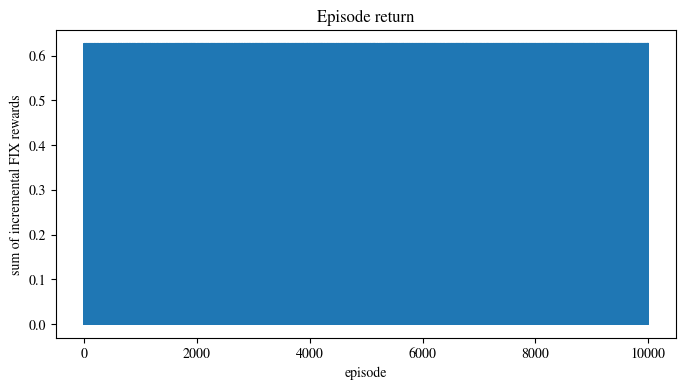

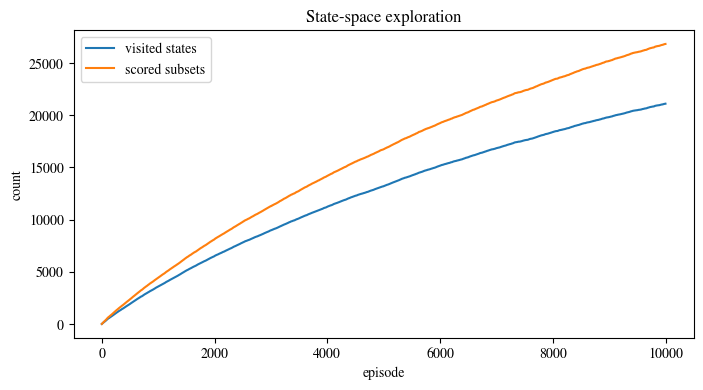

In [37]:
rl_train_df = paper_rl["train_df"]
display(rl_train_df.tail())

plt.figure(figsize=(8, 4))
plt.plot(rl_train_df["episode"], rl_train_df["episode_best_fix"], label="episode best FIX")
plt.plot(rl_train_df["episode"], rl_train_df["global_best_fix"], label="global best FIX")
plt.xlabel("episode")
plt.ylabel("FIX")
plt.title("Paper-aligned RL training curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(rl_train_df["episode"], rl_train_df["episode_return"])
plt.xlabel("episode")
plt.ylabel("sum of incremental FIX rewards")
plt.title("Episode return")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(rl_train_df["episode"], rl_train_df["visited_states"], label="visited states")
plt.plot(rl_train_df["episode"], rl_train_df["cache_size"], label="scored subsets")
plt.xlabel("episode")
plt.ylabel("count")
plt.title("State-space exploration")
plt.legend()
plt.show()


greedy RL rollout metrics: {'fix': 0.6261469721794128, 'p_void_': 0.6317926049232483, 'p_cluster_': 0.0013596916105598211, 'purity': 0.6261469721794128, 'div': 1.0, 'num_groups': 1}
best seen RL state: (0, 1, 2, 3)
best seen RL metrics: {'fix': 0.6261469721794128, 'p_void_': 0.5528266429901123, 'p_cluster_': 0.0017188384663313627, 'purity': 0.5472700595855713, 'div': 1.0, 'num_groups': 4}
hybrid refined metrics: {'fix': 0.6261469721794128, 'p_void_': 0.5528266429901123, 'p_cluster_': 0.0017188384663313627, 'purity': 0.5472700595855713, 'div': 1.0, 'num_groups': 4}


,step,selected,fix,div,num_groups,choice,marginal_gain
0,0,[],0.000000,1.0,0,NaN,NaN
1,1,[1],0.626147,1.0,1,1.0,0.626147


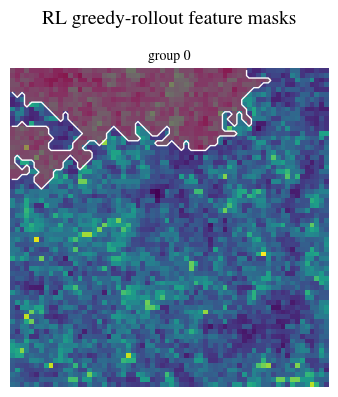

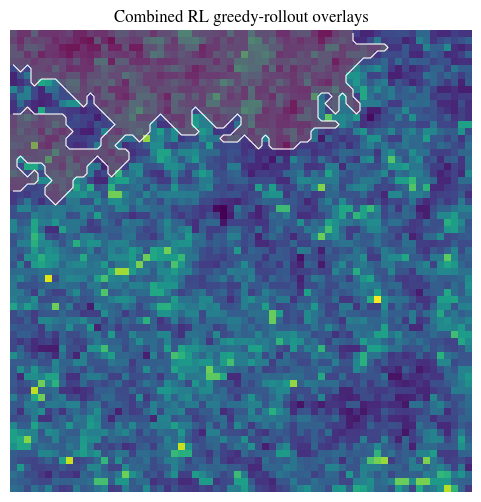

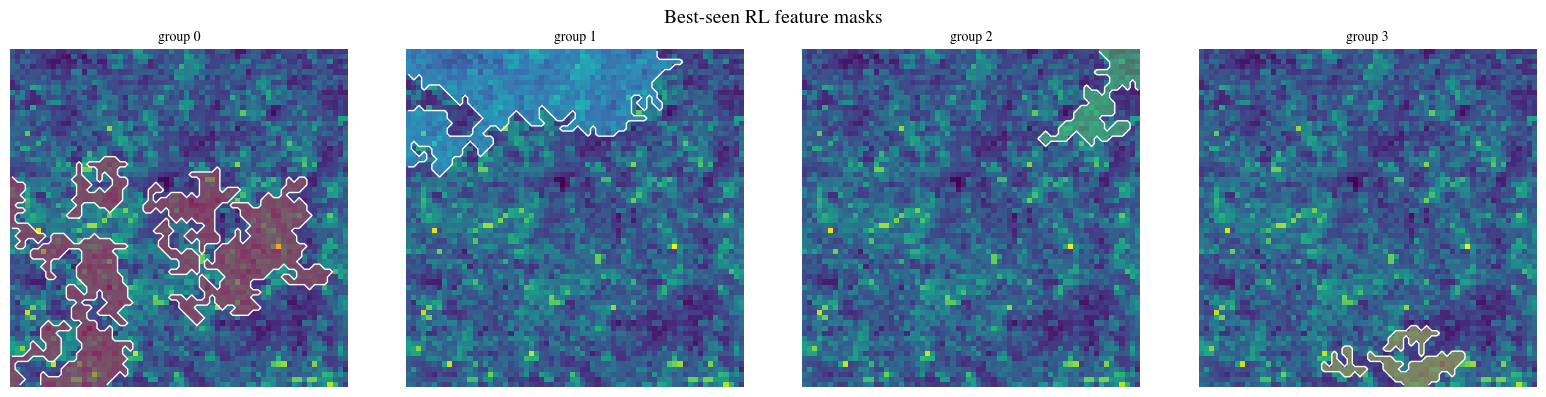

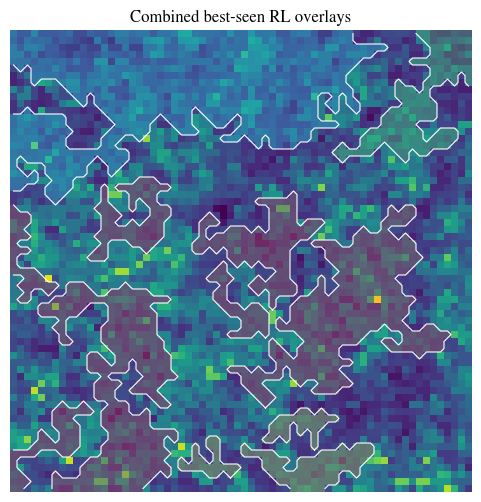

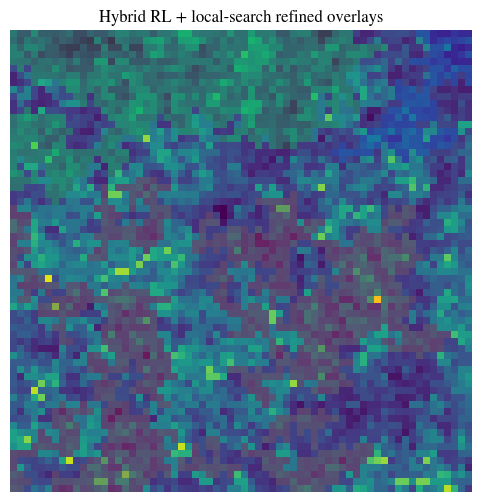

In [38]:

rl_state, rl_rollout_df, rl_metrics = greedy_rollout_from_aor(
    fix_scorer=massmaps_fix,
    image_tensor=image_tensor,
    candidate_bank=bank["groups"],
    rl_artifact=paper_rl,
    start_state=[],
    max_groups=MAX_GROUPS,
)

best_seen_state = paper_rl["best_state"]
best_seen_metrics = paper_rl["best_metrics"]
_, hybrid_metrics, hybrid_groups = refine_state_with_local_search(
    fix_scorer=massmaps_fix,
    image_tensor=image_tensor,
    candidate_bank=bank["groups"],
    state=best_seen_state,
    num_steps=48,
    max_groups=MAX_GROUPS,
    seed=0,
)

print("greedy RL rollout metrics:", rl_metrics)
print("best seen RL state:", best_seen_state)
print("best seen RL metrics:", best_seen_metrics)
print("hybrid refined metrics:", hybrid_metrics)
display(rl_rollout_df)

plot_selected_features(bank["image01"], bank["groups"], rl_state, "RL greedy-rollout feature masks")
overlay_many_masks(bank["image01"], bank["groups"], rl_state, "Combined RL greedy-rollout overlays")

plot_selected_features(bank["image01"], bank["groups"], best_seen_state, "Best-seen RL feature masks")
overlay_many_masks(bank["image01"], bank["groups"], best_seen_state, "Combined best-seen RL overlays")

plt.figure(figsize=(6, 6))
plt.imshow(bank["image01"], cmap="viridis")
for j, g in enumerate(hybrid_groups):
    rgba = np.zeros((*g.shape, 4), dtype=np.float32)
    rgba[..., :3] = np.array([(j % 3 == 0), (j % 3 == 1), (j % 3 == 2)], dtype=np.float32)
    rgba[..., 3] = 0.18 * g.astype(np.float32)
    plt.imshow(rgba)
plt.title("Hybrid RL + local-search refined overlays")
plt.axis("off")
plt.show()


## Small-batch evaluation with stronger paper-style RL + hybrid refinement

In [39]:

def evaluate_methods_on_subset_paper_rl(
    dataset,
    indices,
    fix_scorer,
    fix_steps=60,
    restarts=6,
    beam_rounds=8,
    max_candidates=32,
    init_groups=4,
    max_groups=8,
    rl_episodes=10000,
):
    rows = []

    for idx in tqdm(indices):
        item = dataset[idx]
        image_tensor = item["input"].unsqueeze(0).float()

        bank = build_candidate_bank_massmaps(
            image_tensor=image_tensor,
            max_candidates=max_candidates,
            min_area=20,
        )
        if len(bank["groups"]) == 0:
            continue

        singleton_df = ranked_singletons(fix_scorer, image_tensor, bank["groups"])
        start_groups = seed_init_groups(bank["groups"], singleton_df, init_groups=init_groups)
        init_metrics = metrics_fix_only(fix_scorer, image_tensor, start_groups)

        _, _, fix_metrics = improve_groups_fix_only(
            fix_scorer=fix_scorer,
            image_tensor=image_tensor,
            init_groups=start_groups,
            candidate_bank=bank["groups"],
            num_steps=fix_steps,
            max_groups=max_groups,
            seed=idx,
        )

        _, _, restart_metrics, _ = run_fix_search_with_restarts(
            fix_scorer=fix_scorer,
            image_tensor=image_tensor,
            candidate_bank=bank["groups"],
            n_restarts=restarts,
            num_steps=max(20, fix_steps // 2),
            init_groups=init_groups,
            max_groups=max_groups,
            seed=idx,
        )

        _, _, beam_metrics, _ = beam_search_fix(
            fix_scorer=fix_scorer,
            image_tensor=image_tensor,
            candidate_bank=bank["groups"],
            beam_width=4,
            expansions_per_state=4,
            num_rounds=beam_rounds,
            max_groups=max_groups,
            seed=idx,
        )

        local_rl = train_feature_rl_td_aor(
            fix_scorer=fix_scorer,
            image_tensor=image_tensor,
            candidate_bank=bank["groups"],
            episodes=rl_episodes,
            alpha=0.12,
            gamma=0.97,
            epsilon_start=0.45,
            epsilon_end=0.03,
            max_groups=max_groups,
            random_start_min=0,
            random_start_max=min(4, max_groups),
            no_improve_patience=16,
            top_action_k=12,
            seed=idx,
        )
        _, _, rl_rollout_metrics = greedy_rollout_from_aor(
            fix_scorer=fix_scorer,
            image_tensor=image_tensor,
            candidate_bank=bank["groups"],
            rl_artifact=local_rl,
            start_state=[],
            max_groups=max_groups,
        )
        rl_best_metrics = local_rl["best_metrics"]
        _, rl_hybrid_metrics, _ = refine_state_with_local_search(
            fix_scorer=fix_scorer,
            image_tensor=image_tensor,
            candidate_bank=bank["groups"],
            state=local_rl["best_state"],
            num_steps=36,
            max_groups=max_groups,
            seed=idx,
        )

        rows.append({
            "index": idx,
            "init_fix": init_metrics["fix"],
            "fix_search": fix_metrics["fix"],
            "restart_search": restart_metrics["fix"],
            "beam_search": beam_metrics["fix"],
            "paper_rl_rollout": rl_rollout_metrics["fix"],
            "paper_rl_best_seen": rl_best_metrics["fix"],
            "paper_rl_hybrid": rl_hybrid_metrics["fix"],
        })

    return pd.DataFrame(rows)


  0%|          | 0/8 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

paper-RL+ episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

,index,init_fix,fix_search,restart_search,beam_search,paper_rl_rollout,paper_rl_best_seen,paper_rl_hybrid
0,0,0.172630,0.482683,0.484086,0.571698,0.172630,0.172630,0.474961
1,1,0.526101,0.576775,0.702030,0.612864,0.569193,0.569193,0.601264
2,2,0.404005,0.516414,0.512767,0.516414,0.512767,0.512767,0.512767
3,3,0.618114,0.680602,0.694382,0.706091,0.618114,0.618114,0.663709
4,4,0.453931,0.599787,0.611101,0.594901,0.575252,0.575252,0.596979
5,5,0.515008,0.851493,0.608686,0.881046,0.525854,0.525854,0.542724
6,6,0.574038,0.865968,0.679002,0.818171,0.679002,0.679002,0.679002
7,7,0.617324,0.703693,0.703693,0.787868,0.703693,0.703693,0.703693


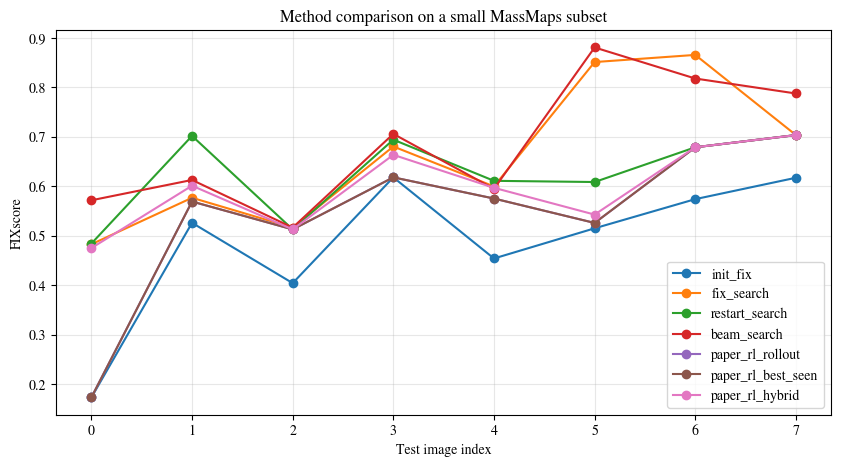

In [40]:

EVAL_INDICES = list(range(min(8, len(test_dataset))))
compare_df = evaluate_methods_on_subset_paper_rl(
    dataset=test_dataset,
    indices=EVAL_INDICES,
    fix_scorer=massmaps_fix,
    fix_steps=60,
    restarts=6,
    beam_rounds=8,
    max_candidates=MAX_CANDIDATES,
    init_groups=INIT_GROUPS,
    max_groups=MAX_GROUPS,
    rl_episodes=10000,
)
display(compare_df)

plt.figure(figsize=(10, 5))
for col in ["init_fix", "fix_search", "restart_search", "beam_search", "paper_rl_rollout", "paper_rl_best_seen", "paper_rl_hybrid"]:
    plt.plot(compare_df["index"], compare_df[col], marker="o", label=col)
plt.xlabel("Test image index")
plt.ylabel("FIXscore")
plt.title("Method comparison on a small MassMaps subset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
